In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import classification_report, ConfusionMatrixDisplay
from imblearn.over_sampling  import SMOTE
from sklearn.preprocessing   import LabelEncoder

print("✅ Imports OK")

✅ Imports OK


In [2]:
from src.build_dataset    import build_ml_dataset
from src.preprocessing_ml import prepare_features

df = build_ml_dataset()

# ✅ Vérification obligatoire avant de continuer
print(f"\nShape df : {df.shape}")
print(f"Gravite unique : {df['gravite'].unique()}")
print(f"Gravite_binaire : {df['gravite_binaire'].value_counts().to_dict()}")

🔍 Query : SELECT * FROM public."ml_dataset_final" 
✅ ml_dataset_final : 506,886 lignes × 64 colonnes
📊 506,886 lignes × 64 colonnes
Mortels : 13,599 / 506,886

Shape df : (506886, 64)
Gravite unique : [ 3.  1.  4.  2. nan]
Gravite_binaire : {0: 493287, 1: 13599}


In [3]:
X, y = prepare_features(df)

# ✅ STOP si moins de 1000 lignes — quelque chose cloche
assert len(y) > 1000, f"❌ Dataset trop petit : {len(y)} lignes — vérifier build_ml_dataset()"
assert y.sum() > 100,  f"❌ Pas assez de mortels : {y.sum()} — vérifier gravite_binaire"

print(f"\n✅ X : {X.shape}")
print(f"✅ Mortels   : {y.sum():,}")
print(f"✅ Non mortels: {(y==0).sum():,}")

✅ X : (506467, 18) | y (mortels) : 13,599 / 506,467 (2.69%)

✅ X : (506467, 18)
✅ Mortels   : 13,599
✅ Non mortels: 492,868


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # ← garantit des mortels dans le test
)

print(f"Train → {y_train.value_counts().to_dict()}")
print(f"Test  → {y_test.value_counts().to_dict()}")

# ✅ STOP si le test n'a pas les 2 classes
assert len(np.unique(y_test)) == 2, "❌ y_test n'a qu'une classe — stratify a échoué"
print("✅ Split OK — 2 classes dans train ET test")

Train → {0: 394294, 1: 10879}
Test  → {0: 98574, 1: 2720}
✅ Split OK — 2 classes dans train ET test


In [5]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"Après SMOTE → {y_train_res.value_counts().to_dict()}")

Après SMOTE → {0: 394294, 1: 394294}


In [6]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_res, y_train_res)
print("✅ Modèle entraîné")

✅ Modèle entraîné


              precision    recall  f1-score   support

  Non mortel       0.99      0.84      0.91     98574
      Mortel       0.09      0.59      0.16      2720

    accuracy                           0.83    101294
   macro avg       0.54      0.71      0.53    101294
weighted avg       0.96      0.83      0.89    101294



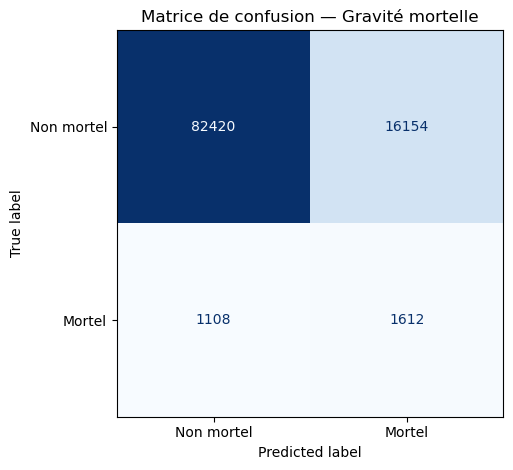

In [7]:
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Non mortel", "Mortel"]))

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test,
                                       display_labels=["Non mortel", "Mortel"],
                                       colorbar=False, cmap="Blues")
plt.title("Matrice de confusion — Gravité mortelle")
plt.tight_layout()
plt.show()

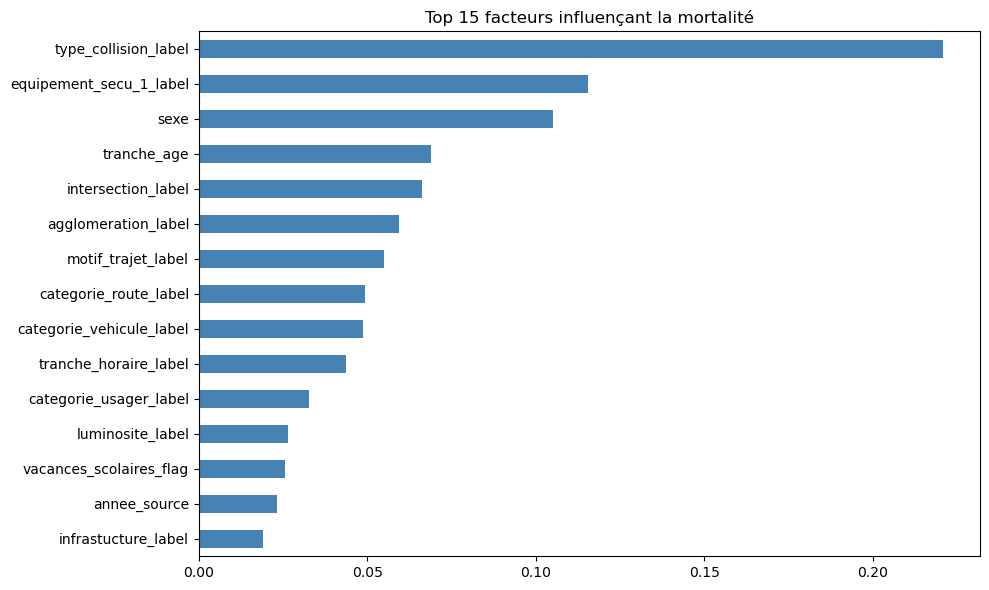

In [8]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns) \
             .sort_values(ascending=False)

feat_imp.head(15).plot(kind="barh", figsize=(10, 6), color="steelblue")
plt.title("Top 15 facteurs influençant la mortalité")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()